In [32]:
import pandas as pd
import matplotlib.pyplot as plt

In [33]:
df = pd.read_csv("../files/embalses_mes.csv")

In [34]:
df['FECHA'] = pd.to_datetime(df['FECHA'])

In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7331 entries, 0 to 7330
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   AMBITO_NOMBRE     7331 non-null   str           
 1   FECHA             7331 non-null   datetime64[us]
 2   PORCENTAJE_LLENO  7329 non-null   float64       
 3   CATEGORIA         7331 non-null   str           
dtypes: datetime64[us](1), float64(1), str(2)
memory usage: 229.2 KB


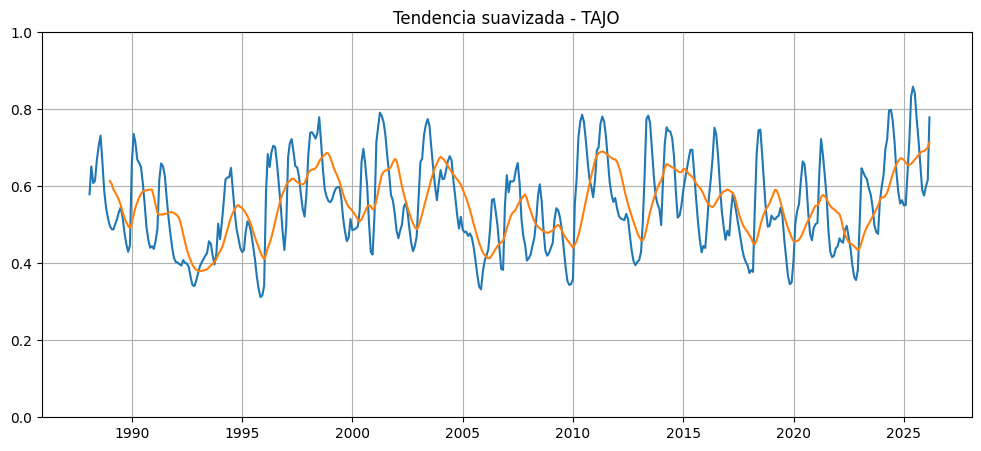

In [36]:
cuenca = "TAJO"

df_plot = df[df["AMBITO_NOMBRE"] == cuenca]

plt.figure(figsize=(12,5))
plt.plot(df_plot["FECHA"], df_plot["PORCENTAJE_LLENO"])

# media móvil 12 meses
plt.plot(
    df_plot["FECHA"],
    df_plot["PORCENTAJE_LLENO"].rolling(12).mean(),
)

plt.title(f"Tendencia suavizada - {cuenca}")
plt.ylim(0,1)
plt.grid(True)
plt.show()

In [37]:
df_volatilidad = (
    df
    .groupby("AMBITO_NOMBRE")["PORCENTAJE_LLENO"]
    .std()
    .sort_values(ascending=False)
)

df_volatilidad

AMBITO_NOMBRE
GUADALETE-BARBATE                  0.234872
GUADALQUIVIR                       0.223140
GUADIANA                           0.212452
CUENCAS INTERNAS DE CATALUÑA       0.208455
SEGURA                             0.164224
CUENCA MEDITERRÁNEA ANDALUZA       0.162649
DUERO                              0.153082
TINTO, ODIEL Y PIEDRAS             0.144724
CANTÁBRICO ORIENTAL                0.140138
JÚCAR                              0.138779
GALICIA COSTA                      0.135009
MIÑO - SIL                         0.134894
CUENCAS INTERNAS DEL PAÍS VASCO    0.134047
EBRO                               0.128737
TAJO                               0.118958
CANTÁBRICO OCCIDENTAL              0.117758
Name: PORCENTAJE_LLENO, dtype: float64

Mayor desviación estándar = más vulnerable a sequías bruscas

In [38]:
df_minimos = (
    df
    .groupby("AMBITO_NOMBRE")["PORCENTAJE_LLENO"]
    .min()
    .sort_values()
)

df_minimos

AMBITO_NOMBRE
GUADALETE-BARBATE                  0.020934
TAJO                               0.062500
SEGURA                             0.072356
JÚCAR                              0.073823
GUADIANA                           0.090856
GUADALQUIVIR                       0.094356
CUENCA MEDITERRÁNEA ANDALUZA       0.102650
CUENCAS INTERNAS DE CATALUÑA       0.149557
CANTÁBRICO ORIENTAL                0.181818
DUERO                              0.296190
TINTO, ODIEL Y PIEDRAS             0.311828
GALICIA COSTA                      0.328216
MIÑO - SIL                         0.330099
EBRO                               0.352371
CANTÁBRICO OCCIDENTAL              0.386157
CUENCAS INTERNAS DEL PAÍS VASCO    0.438095
Name: PORCENTAJE_LLENO, dtype: float64

qué cuencas han tenido peores mínimos históricos

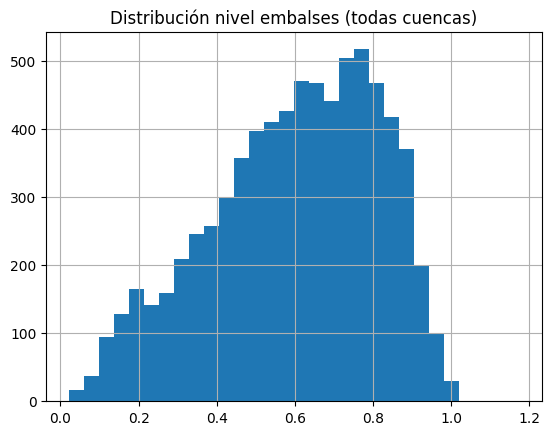

In [39]:
df["PORCENTAJE_LLENO"].hist(bins=30)
plt.title("Distribución nivel embalses (todas cuencas)")
plt.show()

la distribución tiene cola a la izquierda
- La mayoría del tiempo las cuencas están bastante llenas
- Pcasionalmente ocurren sequías severas
- Esos episodios son extremos pero poco frecuentes

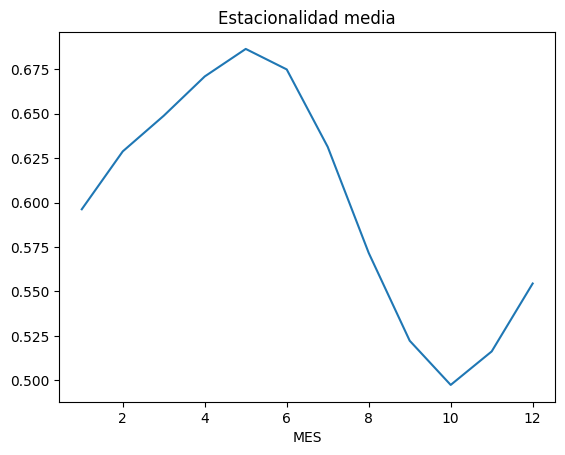

In [40]:
df["MES"] = df["FECHA"].dt.month

df_estacionalidad = (
    df
    .groupby("MES")["PORCENTAJE_LLENO"]
    .mean()
)

df_estacionalidad.plot()
plt.title("Estacionalidad media")
plt.show()

se observa una estacionalidad fuerte

In [41]:
df["SEQUIA"] = df["PORCENTAJE_LLENO"] < 0.4

df_sequia_freq = (
    df
    .groupby("AMBITO_NOMBRE")["SEQUIA"]
    .mean()
    .sort_values(ascending=False)
)

df_sequia_freq

AMBITO_NOMBRE
SEGURA                             0.788210
JÚCAR                              0.556769
GUADALQUIVIR                       0.382096
CUENCA MEDITERRÁNEA ANDALUZA       0.331878
GUADALETE-BARBATE                  0.301310
GUADIANA                           0.281659
CUENCAS INTERNAS DE CATALUÑA       0.187773
TAJO                               0.086768
DUERO                              0.056769
TINTO, ODIEL Y PIEDRAS             0.026201
EBRO                               0.024017
CANTÁBRICO ORIENTAL                0.019651
GALICIA COSTA                      0.015284
MIÑO - SIL                         0.013100
CANTÁBRICO OCCIDENTAL              0.002183
CUENCAS INTERNAS DEL PAÍS VASCO    0.000000
Name: SEQUIA, dtype: float64

La cuenca con más sequías es la del segura, estando el 78% del iempo por debajo de 40% de su capacidad

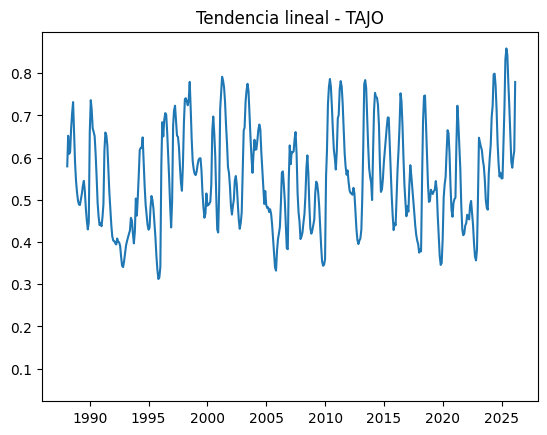

In [42]:
import numpy as np

df_plot = df[df["AMBITO_NOMBRE"] == cuenca]

x = np.arange(len(df_plot))
y = df_plot["PORCENTAJE_LLENO"].values

coef = np.polyfit(x, y, 1)
tendencia = np.poly1d(coef)

plt.plot(df_plot["FECHA"], y)
plt.plot(df_plot["FECHA"], tendencia(x))
plt.title(f"Tendencia lineal - {cuenca}")
plt.show()

## Detectar períodos de sequía prolongada

In [43]:
# Definir sequía (umbral)
df = df.sort_values(["AMBITO_NOMBRE","FECHA"]).copy()
df["SEQUIA"] = df["PORCENTAJE_LLENO"] < 0.4

In [44]:
# Identificar rachas consecutivas de sequía
df["grp"] = (
    df
    .groupby("AMBITO_NOMBRE")["SEQUIA"]
    .apply(lambda s: (s != s.shift()).cumsum())
    .reset_index(level=0, drop=True)
)

In [45]:
# Resumir cada racha
rachas = (
    df[df["SEQUIA"]]
    .groupby(["AMBITO_NOMBRE","grp"])
    .agg(
        inicio=("FECHA","min"),
        fin=("FECHA","max"),
        duracion_meses=("FECHA","count"),
        min_lleno=("PORCENTAJE_LLENO","min"),
        media_lleno=("PORCENTAJE_LLENO","mean")
    )
    .reset_index()
)

rachas.head()

,AMBITO_NOMBRE,grp,inicio,fin,duracion_meses,min_lleno,media_lleno
0,CANTÁBRICO OCCIDENTAL,2,1999-09-30,1999-09-30,1,0.386157,0.386157
1,CANTÁBRICO ORIENTAL,2,1989-10-31,1990-04-30,7,0.181818,0.248810
2,CANTÁBRICO ORIENTAL,4,1995-12-31,1996-01-31,2,0.369014,0.381690
3,CUENCA MEDITERRÁNEA ANDALUZA,2,1988-09-30,1989-01-31,5,0.356645,0.373174
4,CUENCA MEDITERRÁNEA ANDALUZA,4,1989-10-31,1989-10-31,1,0.387613,0.387613


In [46]:
# Filtrar sequías prolongadas
sequias_largas = rachas[rachas["duracion_meses"] >= 6].sort_values(
    ["duracion_meses","min_lleno"], ascending=[False, True]
)

sequias_largas.head(10)

,AMBITO_NOMBRE,grp,inicio,fin,duracion_meses,min_lleno,media_lleno
93,SEGURA,3,1998-08-31,2010-01-31,138,0.093888,0.199668
92,SEGURA,1,1988-01-31,1998-01-31,121,0.072356,0.194092
82,JÚCAR,9,1998-09-30,2004-04-30,68,0.115660,0.264234
83,JÚCAR,11,2004-08-31,2010-01-31,66,0.118530,0.250482
72,GUADIANA,8,1991-06-30,1996-01-31,56,0.090856,0.177730
80,JÚCAR,5,1992-07-31,1997-01-31,55,0.073823,0.202344
56,GUADALQUIVIR,6,1991-07-31,1996-01-31,55,0.094356,0.192615
95,SEGURA,7,2016-05-31,2020-03-31,47,0.132778,0.265314
53,GUADALETE-BARBATE,16,2021-07-31,2025-02-28,44,0.144882,0.262680
47,GUADALETE-BARBATE,4,1992-07-31,1996-01-31,43,0.020934,0.123812


In [47]:
ranking = (
    sequias_largas
    .groupby("AMBITO_NOMBRE")
    .agg(
        n_sequias=("duracion_meses","count"),
        duracion_media=("duracion_meses","mean"),
        peor_min=("min_lleno","min")
    )
    .sort_values(["duracion_media","peor_min"], ascending=[False, True])
)

ranking

,n_sequias,duracion_media,peor_min
AMBITO_NOMBRE,,,
SEGURA,5,71.200000,0.072356
JÚCAR,6,39.833333,0.073823
GUADALETE-BARBATE,4,30.250000,0.020934
GUADIANA,6,20.000000,0.090856
CUENCA MEDITERRÁNEA ANDALUZA,7,18.428571,0.102650
GUADALQUIVIR,10,15.400000,0.094356
CUENCAS INTERNAS DE CATALUÑA,5,14.200000,0.149557
TAJO,1,8.000000,0.340609
CANTÁBRICO ORIENTAL,1,7.000000,0.181818


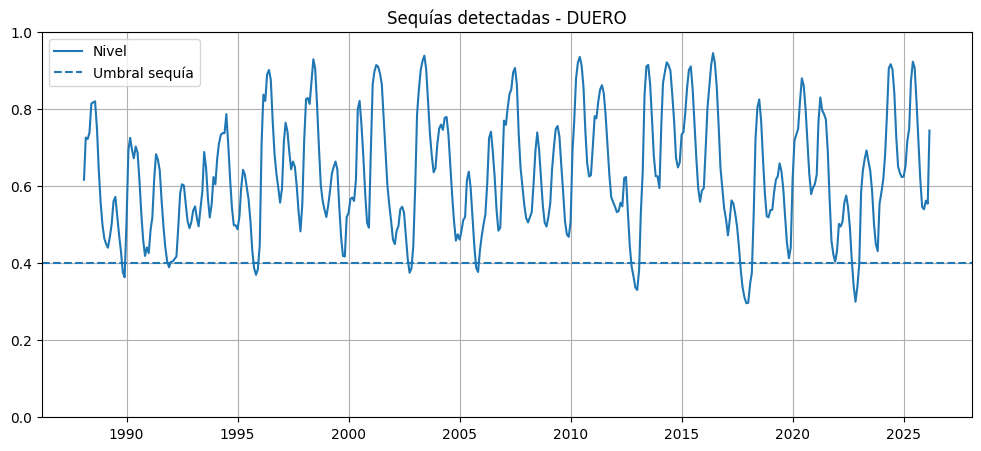

In [48]:
cuenca = "DUERO"

df_plot = df[df["AMBITO_NOMBRE"] == cuenca]

plt.figure(figsize=(12,5))
plt.plot(df_plot["FECHA"], df_plot["PORCENTAJE_LLENO"], label="Nivel")

plt.axhline(0.4, linestyle="--", label="Umbral sequía")

plt.title(f"Sequías detectadas - {cuenca}")
plt.ylim(0,1)
plt.legend()
plt.grid(True)
plt.show()

## Ránking de cuencas por riesgo hídrico

In [56]:
# Media histórica de llenado
media_lleno = (df
               .groupby("AMBITO_NOMBRE")["PORCENTAJE_LLENO"]
               .mean()
               .rename("media_lleno")
)
media_lleno

AMBITO_NOMBRE
CANTÁBRICO OCCIDENTAL              0.741367
CANTÁBRICO ORIENTAL                0.753975
CUENCA MEDITERRÁNEA ANDALUZA       0.487085
CUENCAS INTERNAS DE CATALUÑA       0.632703
CUENCAS INTERNAS DEL PAÍS VASCO    0.808712
DUERO                              0.630423
EBRO                               0.670891
GALICIA COSTA                      0.676225
GUADALETE-BARBATE                  0.527423
GUADALQUIVIR                       0.507027
GUADIANA                           0.533181
JÚCAR                              0.371422
MIÑO - SIL                         0.663895
SEGURA                             0.290823
TAJO                               0.551319
TINTO, ODIEL Y PIEDRAS             0.753609
Name: media_lleno, dtype: float64

In [57]:
# Frecuencia de sequías
df["SEQUIA"] = df["PORCENTAJE_LLENO"] < 0.4

frecuencia_sequia = (
    df
    .groupby("AMBITO_NOMBRE")["SEQUIA"]
    .mean()
    .rename("frecuencia_sequia")
)
frecuencia_sequia

AMBITO_NOMBRE
CANTÁBRICO OCCIDENTAL              0.002183
CANTÁBRICO ORIENTAL                0.019651
CUENCA MEDITERRÁNEA ANDALUZA       0.331878
CUENCAS INTERNAS DE CATALUÑA       0.187773
CUENCAS INTERNAS DEL PAÍS VASCO    0.000000
DUERO                              0.056769
EBRO                               0.024017
GALICIA COSTA                      0.015284
GUADALETE-BARBATE                  0.301310
GUADALQUIVIR                       0.382096
GUADIANA                           0.281659
JÚCAR                              0.556769
MIÑO - SIL                         0.013100
SEGURA                             0.788210
TAJO                               0.086768
TINTO, ODIEL Y PIEDRAS             0.026201
Name: frecuencia_sequia, dtype: float64

In [58]:
# Volatilidad

volatilidad = (
    df
    .groupby("AMBITO_NOMBRE")["PORCENTAJE_LLENO"]
    .std()
    .rename("volatilidad")
)
volatilidad

AMBITO_NOMBRE
CANTÁBRICO OCCIDENTAL              0.117758
CANTÁBRICO ORIENTAL                0.140138
CUENCA MEDITERRÁNEA ANDALUZA       0.162649
CUENCAS INTERNAS DE CATALUÑA       0.208455
CUENCAS INTERNAS DEL PAÍS VASCO    0.134047
DUERO                              0.153082
EBRO                               0.128737
GALICIA COSTA                      0.135009
GUADALETE-BARBATE                  0.234872
GUADALQUIVIR                       0.223140
GUADIANA                           0.212452
JÚCAR                              0.138779
MIÑO - SIL                         0.134894
SEGURA                             0.164224
TAJO                               0.118958
TINTO, ODIEL Y PIEDRAS             0.144724
Name: volatilidad, dtype: float64

In [59]:
# Mínimo Histórico

minimo = (
    df
    .groupby("AMBITO_NOMBRE")["PORCENTAJE_LLENO"]
    .min()
    .rename("minimo_historico")
)
minimo

AMBITO_NOMBRE
CANTÁBRICO OCCIDENTAL              0.386157
CANTÁBRICO ORIENTAL                0.181818
CUENCA MEDITERRÁNEA ANDALUZA       0.102650
CUENCAS INTERNAS DE CATALUÑA       0.149557
CUENCAS INTERNAS DEL PAÍS VASCO    0.438095
DUERO                              0.296190
EBRO                               0.352371
GALICIA COSTA                      0.328216
GUADALETE-BARBATE                  0.020934
GUADALQUIVIR                       0.094356
GUADIANA                           0.090856
JÚCAR                              0.073823
MIÑO - SIL                         0.330099
SEGURA                             0.072356
TAJO                               0.062500
TINTO, ODIEL Y PIEDRAS             0.311828
Name: minimo_historico, dtype: float64

In [60]:
ranking = pd.concat(
    [media_lleno, frecuencia_sequia, volatilidad, minimo],
    axis = 1
)
ranking.head()

,media_lleno,frecuencia_sequia,volatilidad,minimo_historico
AMBITO_NOMBRE,,,,
CANTÁBRICO OCCIDENTAL,0.741367,0.002183,0.117758,0.386157
CANTÁBRICO ORIENTAL,0.753975,0.019651,0.140138,0.181818
CUENCA MEDITERRÁNEA ANDALUZA,0.487085,0.331878,0.162649,0.102650
CUENCAS INTERNAS DE CATALUÑA,0.632703,0.187773,0.208455,0.149557
CUENCAS INTERNAS DEL PAÍS VASCO,0.808712,0.000000,0.134047,0.438095


In [61]:
# Crear score de riesgo

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

ranking_scaled = pd.DataFrame(
    scaler.fit_transform(ranking),
    columns=ranking.columns,
    index=ranking.index
)

#invertimos la media porque menos agua = mas riesgo
ranking_scaled["media_lleno"] = 1 - ranking_scaled["media_lleno"]
ranking_scaled["minimo_historico"] = 1 - ranking_scaled["minimo_historico"]

In [62]:
# score final

ranking["riesgo_hidrico"] = ranking_scaled.mean(axis=1)

ranking = ranking.sort_values("riesgo_hidrico", ascending=False)

ranking

,media_lleno,frecuencia_sequia,volatilidad,minimo_historico,riesgo_hidrico
AMBITO_NOMBRE,,,,,
SEGURA,0.290823,0.788210,0.164224,0.072356,0.818373
GUADALETE-BARBATE,0.527423,0.301310,0.234872,0.020934,0.731354
GUADALQUIVIR,0.507027,0.382096,0.223140,0.094356,0.697778
JÚCAR,0.371422,0.556769,0.138779,0.073823,0.650863
GUADIANA,0.533181,0.281659,0.212452,0.090856,0.632581
CUENCA MEDITERRÁNEA ANDALUZA,0.487085,0.331878,0.162649,0.102650,0.557379
CUENCAS INTERNAS DE CATALUÑA,0.632703,0.187773,0.208455,0.149557,0.511049
TAJO,0.551319,0.086768,0.118958,0.062500,0.379424
DUERO,0.630423,0.056769,0.153082,0.296190,0.264518


Las cuencas del sureste español presentan el mayor riesgo hídrico histórico

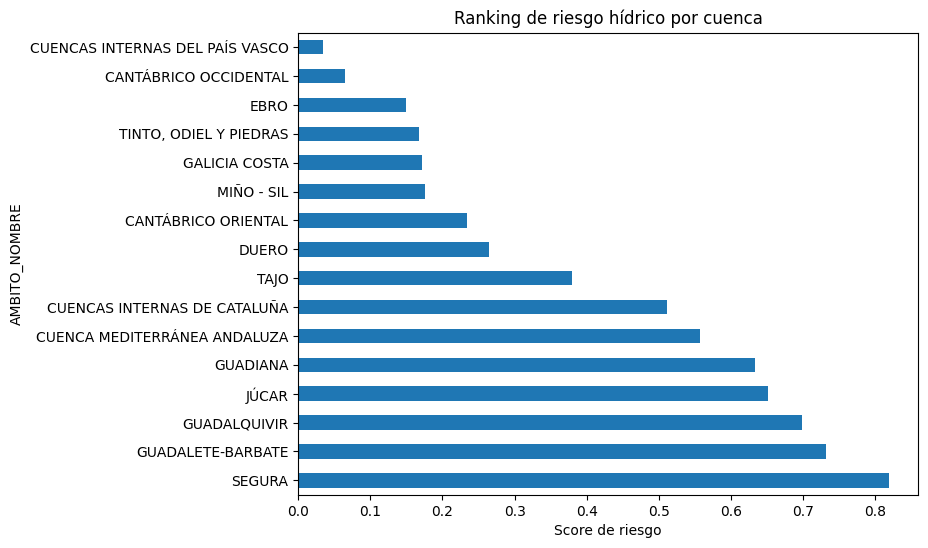

In [63]:
ranking["riesgo_hidrico"].plot(kind="barh", figsize=(8,6))
plt.title("Ranking de riesgo hídrico por cuenca")
plt.xlabel("Score de riesgo")
plt.show()

## Heatmap histórico de sequías

In [ ]:
# Crear columna AÑO
df["AÑO"] = df["FECHA"].dt.year

In [ ]:
# Calcular frecuencia de sequía por año
df_sequia_anual = (
    df
    .groupby(["AMBITO_NOMBRE","AÑO"])["SEQUIA"]
    .mean()
    .reset_index()
)
df_sequia_anual

,AMBITO_NOMBRE,AÑO,SEQUIA
0,CANTÁBRICO OCCIDENTAL,1988,0.0
1,CANTÁBRICO OCCIDENTAL,1989,0.0
2,CANTÁBRICO OCCIDENTAL,1990,0.0
3,CANTÁBRICO OCCIDENTAL,1991,0.0
4,CANTÁBRICO OCCIDENTAL,1992,0.0
...,...,...,...
620,"TINTO, ODIEL Y PIEDRAS",2022,0.0
621,"TINTO, ODIEL Y PIEDRAS",2023,0.0
622,"TINTO, ODIEL Y PIEDRAS",2024,0.0
623,"TINTO, ODIEL Y PIEDRAS",2025,0.0


In [ ]:
# Convertir a matriz
heatmap_sequia = df_sequia_anual.pivot(
    index="AMBITO_NOMBRE",
    columns="AÑO",
    values="SEQUIA"
)

In [ ]:
heatmap_sequia = heatmap_sequia.loc[ranking.index]
heatmap_sequia

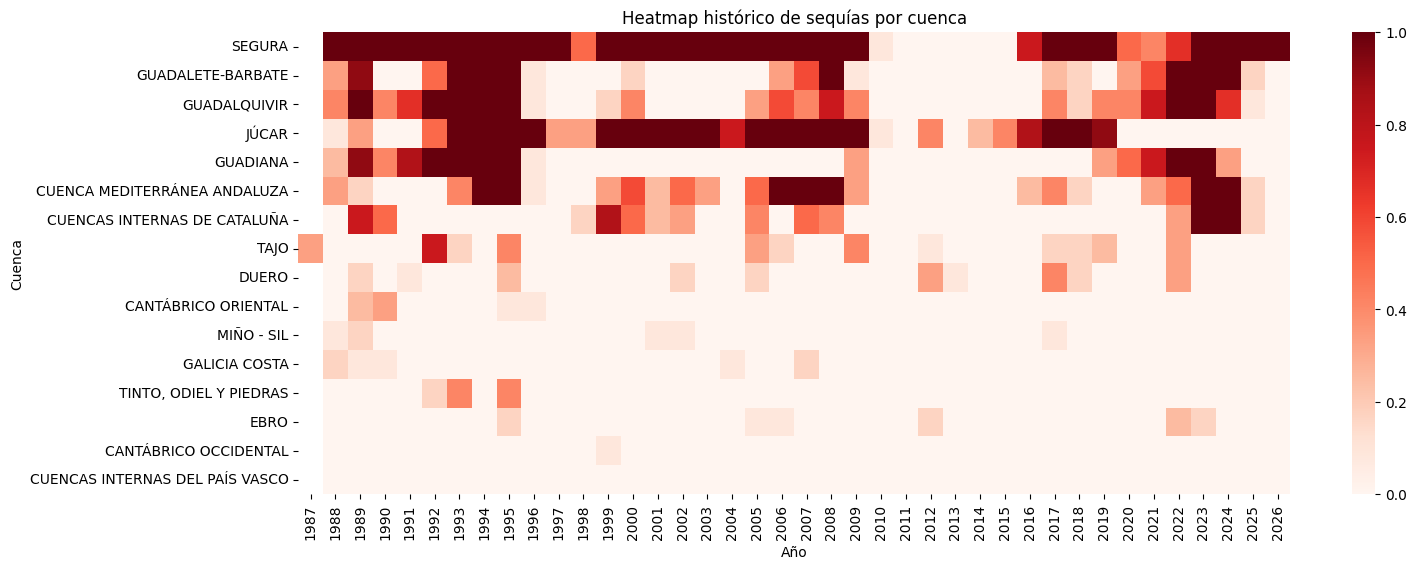

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))

sns.heatmap(
    heatmap_sequia,
    cmap="Reds",
    vmin=0,
    vmax=1
)

plt.title("Heatmap histórico de sequías por cuenca")
plt.xlabel("Año")
plt.ylabel("Cuenca")

plt.show()